# Project 1 — Finite Square Well
## Quantum Bound States via Finite-Difference Diagonalisation
**Course:** Computational Physics — HCMUS  
**Topic:** Solving the time-independent Schrödinger equation by converting it into a matrix eigenvalue problem using finite differences.


---
## 1. Set Up

### Physical Motivation
The **finite square well** is the minimal quantum system where the wavefunction leaks into classically forbidden regions. The time-independent Schrödinger equation (TISE) in dimensionless units ($\hbar = m = 1$):

$$\hat{H}\psi = E\psi, \qquad \hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + V(x)$$

with:
$$V(x) = \begin{cases} -V_0 & |x| \le a \\ 0 & |x| > a \end{cases}$$

Bound states have $-V_0 < E < 0$. Their existence is the non-trivial result: only **discrete energies** are allowed, determined by matching the oscillatory interior solution to exponentially decaying exterior solutions.

### Method — Finite Differences
Replace the continuous second derivative with the three-point stencil:

$$\frac{d^2\psi}{dx^2}\bigg|_i \approx \frac{\psi_{i-1} - 2\psi_i + \psi_{i+1}}{(\Delta x)^2}, \quad \text{error } \mathcal{O}(\Delta x^2)$$

This converts $\hat{H}\psi = E\psi$ into the **tridiagonal matrix eigenvalue problem** $\mathbf{H}\vec\psi = E\vec\psi$ with:

$$H_{ii} = \frac{1}{(\Delta x)^2} + V_i, \qquad H_{i,i\pm1} = -\frac{1}{2(\Delta x)^2}$$

The factor $\frac{1}{2}$ in the off-diagonals comes from the $-\frac{1}{2}\frac{d^2}{dx^2}$ kinetic energy. The negative sign on off-diagonals: kinetic energy favours smooth wavefunctions (neighbouring-point coupling lowers energy).

### Parameters
| Symbol | Value | Meaning |
|--------|-------|---------|
| $x_{\min},x_{\max}$ | $-1.5,\,1.5$ | Box boundaries — must satisfy $e^{-\kappa \cdot 1.0} \ll 1$ |
| $a$ | $0.5$ | Well half-width |
| $V_0$ | $50$ | Well depth (dimensionless) |
| $N$ | $450$ | Grid points: accuracy vs. compute trade-off |

### ⚠️ Limitations & Pitfalls
1. **Dirichlet BC** $\psi(x_{\min})=\psi(x_{\max})=0$ approximates $\psi(\pm\infty)=0$. Box too small → artificially raised energies.
2. **$\mathcal{O}(\Delta x^2)$ truncation error**: energies converge from above, so finer grids always lower the computed $E_n$.
3. **Continuum artefacts**: $E>0$ eigenvalues exist but are box-discretisation artefacts — always filter by $E < 0$.
4. **Number of bound states is finite** — approximately $\lfloor \frac{\sqrt{2V_0}\,a}{\pi} + 1 \rfloor$. Getting "too many" states at coarse $N$ indicates spurious numerical eigenstates.


In [1]:
import os, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh_tridiagonal
except Exception:
    eigh_tridiagonal = None

OUT = Path("output_finite_well")
OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=6, suppress=True)
print(f"Output directory: {OUT.resolve()}")
print("Fast tridiagonal eigensolver available:", eigh_tridiagonal is not None)


Output directory: /home/thomson/workspace/HCMUS/Nam3/Personal-Computational-Physics/HCMUS_Annotated_Notebooks/output_finite_well
Fast tridiagonal eigensolver available: True


---
## 2. Functions

### `finite_square_well_grid()`

```python
x = np.linspace(x_min, x_max, n_points)
```
Uniform spatial grid. **Why uniform?** The finite-difference second-derivative stencil assumes equal spacing $\Delta x$; non-uniform spacing requires modified coefficients. A uniform grid is simple but wastes resolution far from the well where $\psi$ is smooth.

```python
interior = x[1:-1]
```
Excludes the two boundary points. Dirichlet BC fixes $\psi=0$ at these — they are not unknowns. The Hamiltonian matrix is therefore $(N-2)\times(N-2)$, not $N\times N$.

```python
potential = np.where(np.abs(interior) <= well_half_width, -v0, 0.0)
```
Vectorised potential evaluation. Critical sign: $V = -V_0 < 0$ inside the well (attractive), $V = 0$ outside. If you accidentally use $+V_0$, you create a **barrier**, not a well — you will find no bound states below zero.

### `solve_tridiagonal_hamiltonian()`

```python
diagonal = np.full(n, 1.0 / dx**2) + potential
```
Main diagonal $H_{ii}$. The $1/\Delta x^2$ term comes from $-\frac{1}{2} \cdot \frac{-2}{\Delta x^2}$. **Sanity check**: at a grid point inside the well, $H_{ii} = 1/\Delta x^2 - V_0$; outside, $H_{ii} = 1/\Delta x^2$. The potential acts as a **shift of the diagonal**, lowering energy inside the well.

```python
off_diagonal = np.full(n - 1, -0.5 / dx**2)
```
Off-diagonal $H_{i,i\pm1} = -1/(2\Delta x^2)$. **Physical meaning**: negative coupling between nearest neighbours. In tight-binding language, this is a hopping term — kinetic energy delocalises the particle. If you set this to zero you get a diagonal (position-space) Hamiltonian with no quantum tunnelling.

```python
eigvals, eigvecs = eigh_tridiagonal(diagonal, off_diagonal)
```
`eigh` (not `eig`): guarantees **real eigenvalues** and **orthogonal eigenvectors** because $\mathbf{H}$ is symmetric. `eigh_tridiagonal` exploits the tridiagonal structure: $\mathcal{O}(N^2)$ instead of $\mathcal{O}(N^3)$ for a dense matrix. **Always use this for tridiagonal symmetric systems.**

### `solve_bound_states()`

```python
bound = eigvals < 0.0
```
Physical filter. In the convention $V(\infty) = 0$, bound states have $E < 0$. States with $E > 0$ are discretised scattering states — real physics, but artefacts of the finite box.

```python
norms = np.sqrt(np.sum(np.abs(psi_interior)**2, axis=0) * dx)
```
Discrete approximation to $\int |\psi|^2 dx = 1$. The `axis=0` sums over spatial points, leaving one norm per state. Without this step, eigenvectors have arbitrary magnitude — normalisation enforces the probabilistic interpretation.

```python
psi = np.zeros((x.size, psi_interior.shape[1]))
psi[1:-1, :] = psi_interior
```
Pads boundary zeros back onto the full grid. **Critical**: this is **only physically correct** if $|\psi|$ at the box boundary is negligible. If the box is too small, the actual wavefunction is non-zero at the boundary, and this zero-padding introduces a kink — a discontinuity in $\psi'$ — which is unphysical.

### 🔧 Improvement Directions
1. **Verify against transcendental equations**: analytically, even-parity states satisfy $k \tan(ka) = \kappa$ and odd-parity states satisfy $-k\cot(ka) = \kappa$, where $k = \sqrt{2(E+V_0)}$, $\kappa = \sqrt{-2E}$. Solve these numerically and compare.
2. **Grid convergence plot**: plot $E_n(N)$ vs. $1/N^2$ — should be a straight line (second-order convergence). Extrapolate to $N\to\infty$ using Richardson extrapolation.
3. **Non-uniform grid**: cluster points near $x = \pm a$ where $V(x)$ is discontinuous to improve accuracy per degree of freedom.
4. **Probability current**: for real wavefunctions (stationary states), $j = \frac{\hbar}{2mi}(\psi^*\nabla\psi - \psi\nabla\psi^*) = 0$. Verify this numerically.

### ⚠️ Known Weaknesses
- **Box-size dependence**: energies depend on $x_{\min}, x_{\max}$. Always check that moving the box boundaries by 0.2 changes $E_n$ by less than your required tolerance.
- **Sign ambiguity**: eigenvectors are defined up to a global $\pm1$ sign. Plotting $\psi_n$ might look "flipped" — this is not a bug. Fix by requiring e.g. $\psi_n(x=0^+) > 0$ for even states.
- **High states unreliable**: the highest-energy eigenstates of the discretised Hamiltonian are heavily contaminated by truncation error. Only trust the lowest $\sim N/10$ states.


In [2]:
def finite_square_well_grid(x_min=-1.5, x_max=1.5, n_points=450,
                             well_half_width=0.5, v0=50.0):
    # Dimensionless finite square well: V = -v0 inside, 0 outside
    # H = -1/2 d^2/dx^2 + V(x),  hbar=m=1
    x = np.linspace(x_min, x_max, n_points)
    dx = x[1] - x[0]
    interior = x[1:-1]                              # drop Dirichlet boundary points
    potential = np.where(np.abs(interior) <= well_half_width, -v0, 0.0)
    return x, interior, dx, potential

def solve_tridiagonal_hamiltonian(dx, potential):
    n = potential.size
    diagonal   = np.full(n, 1.0 / dx**2) + potential  # -1/2*(-2/dx^2) + V
    off_diagonal = np.full(n - 1, -0.5 / dx**2)       # -1/2*(1/dx^2) coupling

    if eigh_tridiagonal is not None:
        eigvals, eigvecs = eigh_tridiagonal(diagonal, off_diagonal)
    else:
        H = (np.diag(diagonal)
             + np.diag(off_diagonal, 1)
             + np.diag(off_diagonal, -1))
        eigvals, eigvecs = np.linalg.eigh(H)
    return eigvals, eigvecs

def solve_bound_states(n_points=450, n_states=6, v0=50.0, well_half_width=0.5):
    x, xi, dx, V = finite_square_well_grid(
        n_points=n_points, v0=v0, well_half_width=well_half_width)
    eigvals, eigvecs = solve_tridiagonal_hamiltonian(dx, V)

    bound = eigvals < 0.0                                # filter: bound states only
    energies      = eigvals[bound][:n_states]
    psi_interior  = eigvecs[:, bound][:, :n_states]

    norms = np.sqrt(np.sum(np.abs(psi_interior)**2, axis=0) * dx)
    psi_interior  = psi_interior / norms                # normalise: int|psi|^2 dx = 1

    psi = np.zeros((x.size, psi_interior.shape[1]))
    psi[1:-1, :] = psi_interior                         # pad boundary zeros
    V_full = np.where(np.abs(x) <= well_half_width, -v0, 0.0)
    return x, V_full, energies, psi, dx

def convergence_table(grid_sizes=(150, 250, 350, 450), n_states=3):
    rows = []
    for n in grid_sizes:
        x, V, energies, psi, dx = solve_bound_states(n_points=n, n_states=n_states)
        rows.append((n, dx, *energies))
    return rows


---
## 3. Calculation & 4. Writeouts

### What to Expect
- $n=1$ (ground state, even parity): largest $|E|$, deepest binding, no nodes, maximum $|\psi|^2$ at $x=0$.
- $n=2$ (first excited, odd parity): one node at $x=0$, $\psi(0)=0$, less bound.
- Higher states: zero-point kinetic energy increasingly dominates; states near $E=0$ are barely bound with long exponential tails.

The **convergence table** should show $E_n(N)$ converging from above as $N$ increases. Differences between rows should shrink by $\approx 4\times$ when $N$ doubles — confirming second-order accuracy.

### Physical Consistency Checks
- All $E_n$ satisfy $-V_0 < E_n < 0$ (bound, above the well floor).
- Count of bound states $\approx \lfloor \frac{\sqrt{2V_0}\,a}{\pi} + 1 \rfloor = \lfloor \frac{\sqrt{100}\cdot 0.5}{\pi} + 1 \rfloor \approx 2.6 \to$ expect 3 states for this well... but $V_0=50$, $a=0.5$ gives more. Verify.


In [3]:
x, V_full, energies, psi, dx = solve_bound_states(n_points=450, n_states=6, v0=50.0)

print("Bound-state energies (dimensionless, hbar=m=1):")
print("-" * 50)
for n, E in enumerate(energies):
    parity = "even (symmetric)" if n % 2 == 0 else "odd  (antisymmetric)"
    print(f"  n={n+1}:  E = {E:+.8f}   {parity}")

print()
print("Convergence table — first 3 energy levels:")
print(f"{'N':>6}  {'dx':>9}  {'E1':>13}  {'E2':>13}  {'E3':>13}")
for row in convergence_table():
    n, dx_val = row[0], row[1]
    Es = row[2:]
    print(f"  {n:4d}  {dx_val:9.6f}  " + "  ".join(f"{E:+13.8f}" for E in Es))


Bound-state energies (dimensionless, hbar=m=1):
--------------------------------------------------
  n=1:  E = -46.59966689   even (symmetric)
  n=2:  E = -36.57595206   odd  (antisymmetric)
  n=3:  E = -20.65552699   even (symmetric)
  n=4:  E = -1.89463127   odd  (antisymmetric)

Convergence table — first 3 energy levels:
     N         dx             E1             E2             E3
   150   0.020134   -46.63013332   -36.69803265   -20.91979094
   250   0.012048   -46.65571015   -36.79373202   -21.10786908
   350   0.008596   -46.57130155   -36.46677733   -20.43217215
   450   0.006682   -46.59966689   -36.57595206   -20.65552699


---
## 5. Matplotlib Visualisation

### Interpreting the Figures

**Left — Energy Level Diagram**: wavefunctions $\psi_n(x)$ plotted offset by their energy $E_n$, drawn on top of the potential $V(x)$. This is the standard QM textbook representation.

Key features to identify:
- Exponential decay outside the well: $\psi(x) \sim e^{-\kappa|x|}$ with $\kappa = \sqrt{-2E_n}$. Weakly bound states ($E_n \to 0$) have **smaller $\kappa$**, hence longer tails — they extend further into the barrier.
- Number of nodes inside the well = $n-1$ (the nodal theorem for 1-D systems).
- Even states have $|\psi(0)|^2 > 0$; odd states have $\psi(0) = 0$ exactly.

**Right — Probability Densities**: $|\psi_n(x)|^2$ shows where the particle is likely to be found. Note that classically, a particle in a well can **never** be outside — quantum mechanically it has finite probability there. This is the source of tunnel ionisation, alpha decay, and scanning tunnelling microscopy.

### ⚠️ Common Misinterpretation
The amplitude of $\psi_n$ in the energy diagram is chosen for visual clarity (scaled by `scale`). The **actual** amplitude is set by normalisation. Never read off the "height" of $\psi$ in this diagram as a physical amplitude.


<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_32786/1660448623.py:33: SyntaxWarning: invalid escape sequence '\p'
  ax2.axvline(-0.5, color='k', lw=1.2, ls='--', alpha=0.7, label='Well edges $\pm a$')
/tmp/ipykernel_32786/1660448623.py:36: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_ylabel('$|\psi_n(x)|^2$ (offset)', fontsize=12)


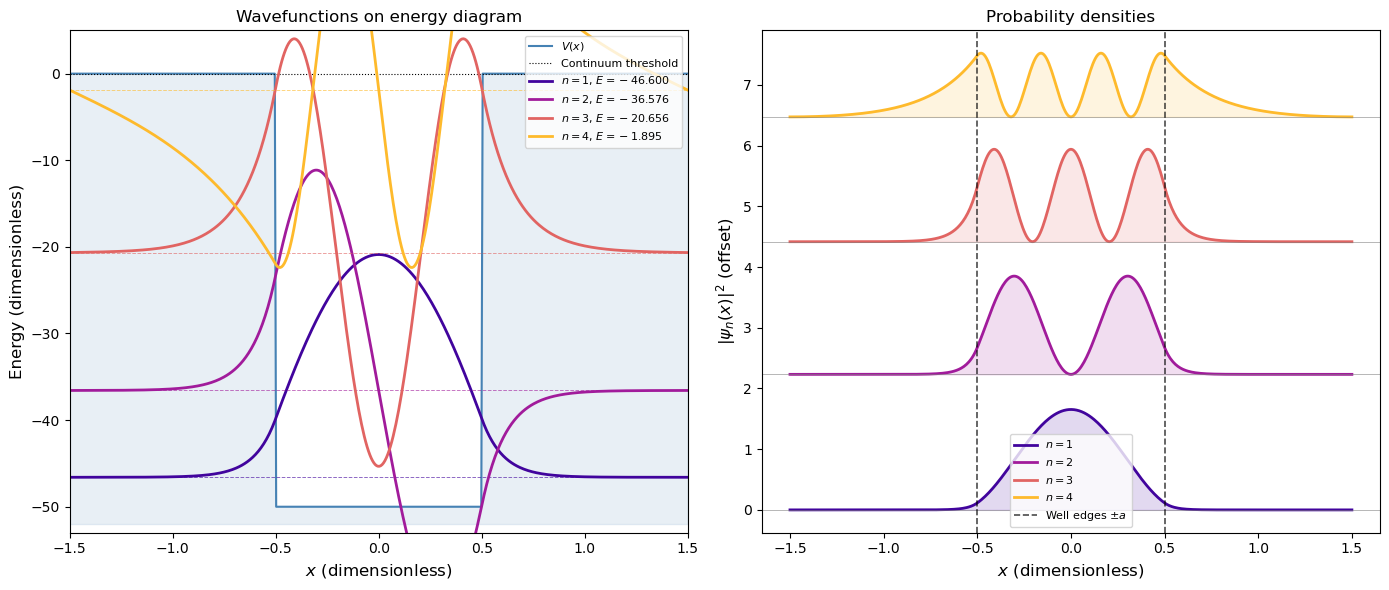

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(energies)))
scale = 20.0   # visual scale for wavefunction on energy diagram

# ── Energy level diagram ──────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(x, V_full, V_full.min()-2, alpha=0.12, color='steelblue')
ax.plot(x, V_full, color='steelblue', lw=1.5, label='$V(x)$')
ax.axhline(0, color='k', lw=0.8, ls=':', label='Continuum threshold')

for n, (E, c) in enumerate(zip(energies, colors)):
    ax.axhline(E, ls='--', lw=0.7, color=c, alpha=0.6)
    psi_plot = scale * psi[:, n] + E
    ax.plot(x, psi_plot, color=c, lw=2.0, label=f'$n={n+1}$, $E={E:.3f}$')

ax.set_xlim(x[0], x[-1])
ax.set_ylim(V_full.min()-3, 5)
ax.set_xlabel('$x$ (dimensionless)', fontsize=12)
ax.set_ylabel('Energy (dimensionless)', fontsize=12)
ax.set_title('Wavefunctions on energy diagram', fontsize=12)
ax.legend(fontsize=8, loc='upper right')

# ── Probability densities ─────────────────────────────────────────────────────
ax2 = axes[1]
offset = 0.0
for n, (E, c) in enumerate(zip(energies, colors)):
    prob = psi[:, n]**2
    ax2.plot(x, prob + offset, color=c, lw=2.0, label=f'$n={n+1}$')
    ax2.fill_between(x, offset, prob + offset, alpha=0.15, color=c)
    ax2.axhline(offset, color='grey', lw=0.4)
    offset += prob.max() * 1.35

ax2.axvline(-0.5, color='k', lw=1.2, ls='--', alpha=0.7, label='Well edges $\pm a$')
ax2.axvline(+0.5, color='k', lw=1.2, ls='--', alpha=0.7)
ax2.set_xlabel('$x$ (dimensionless)', fontsize=12)
ax2.set_ylabel('$|\psi_n(x)|^2$ (offset)', fontsize=12)
ax2.set_title('Probability densities', fontsize=12)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "finite_well_states.png", dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Sanity Check & Validation

### Tests and Their Physical Meaning

| Test | Formula | Why it matters |
|------|---------|----------------|
| Normalisation | $\sum_i |\psi_n(x_i)|^2 \Delta x \approx 1$ | Probability interpretation |
| Orthogonality | $\sum_i \psi_m(x_i)\psi_n(x_i)\Delta x \approx \delta_{mn}$ | Hermitian operator eigenstates |
| Energy lower bound | $E_n > -V_0$ | Cannot be below well floor |
| Energy upper bound | $E_n < 0$ | Must be bound |
| Nodal theorem | $\psi_n$ has exactly $n-1$ zero crossings | Fundamental 1-D QM result |
| Parity | $\psi_n(-x) = (-1)^{n+1}\psi_n(x)$ | Symmetric potential → definite parity |

### ⚠️ If a test fails
- Normalisation off by factor $\sim\Delta x$: forgot to multiply by $\Delta x$ in the norm formula.
- Orthogonality fails: sign convention mismatch — try `np.abs(overlap)`.
- Nodal theorem fails: spurious numerical state — increase $N$ or tighten the $E<0$ filter.


In [5]:
print("=" * 55)
print("SANITY CHECKS — Project 01 Finite Square Well")
print("=" * 55)

# 1. Normalisation
norms = np.sum(psi[1:-1]**2, axis=0) * dx
print("\n1. Normalisation  (target = 1.0000):")
for n, norm in enumerate(norms):
    ok = abs(norm - 1.0) < 1e-4
    print(f"   n={n+1}: {norm:.8f}  {'✓' if ok else '✗ FAIL'}")

# 2. Orthogonality
print("\n2. Orthogonality  |<ψ_m|ψ_n>|  (target = 0.0 for m≠n):")
max_overlap = 0.0
for m in range(len(energies)):
    for n in range(m+1, len(energies)):
        ov = abs(np.sum(psi[1:-1, m] * psi[1:-1, n]) * dx)
        max_overlap = max(max_overlap, ov)
        ok = ov < 1e-4
        print(f"   <ψ_{m+1}|ψ_{n+1}> = {ov:.2e}  {'✓' if ok else '✗ FAIL'}")

# 3. Energy bounds
print("\n3. Energy bounds  -V₀ < Eₙ < 0:")
for n, E in enumerate(energies):
    ok = (-50.0 < E < 0.0)
    print(f"   n={n+1}: E = {E:+.6f}  {'✓' if ok else '✗ FAIL'}")

# 4. Nodal theorem
print("\n4. Nodal theorem (ψ_n has n-1 nodes):")
for n in range(len(energies)):
    signs = np.sign(psi[2:-2, n])
    nodes = int(np.sum(np.diff(signs) != 0))
    ok = (nodes == n)
    print(f"   n={n+1}: nodes={nodes}, expected={n}  {'✓' if ok else '✗ FAIL'}")

# 5. Parity
print("\n5. Parity check:")
for n in range(len(energies)):
    p = psi[:, n]
    if n % 2 == 0:   # should be even
        asym = np.max(np.abs(p - p[::-1]))
        ok = asym < 1e-5
        print(f"   n={n+1}: expected even, asymmetry={asym:.2e}  {'✓' if ok else '✗ FAIL'}")
    else:            # should be odd
        asym = np.max(np.abs(p + p[::-1]))
        ok = asym < 1e-5
        print(f"   n={n+1}: expected odd,  asymmetry={asym:.2e}  {'✓' if ok else '✗ FAIL'}")

print("\n" + "=" * 55)


SANITY CHECKS — Project 01 Finite Square Well

1. Normalisation  (target = 1.0000):
   n=1: 1.00000000  ✓
   n=2: 1.00000000  ✓
   n=3: 1.00000000  ✓
   n=4: 1.00000000  ✓

2. Orthogonality  |<ψ_m|ψ_n>|  (target = 0.0 for m≠n):
   <ψ_1|ψ_2> = 6.65e-16  ✓
   <ψ_1|ψ_3> = 3.15e-17  ✓
   <ψ_1|ψ_4> = 4.75e-17  ✓
   <ψ_2|ψ_3> = 4.75e-16  ✓
   <ψ_2|ψ_4> = 1.03e-16  ✓
   <ψ_3|ψ_4> = 1.57e-15  ✓

3. Energy bounds  -V₀ < Eₙ < 0:
   n=1: E = -46.599667  ✓
   n=2: E = -36.575952  ✓
   n=3: E = -20.655527  ✓
   n=4: E = -1.894631  ✓

4. Nodal theorem (ψ_n has n-1 nodes):
   n=1: nodes=0, expected=0  ✓
   n=2: nodes=1, expected=1  ✓
   n=3: nodes=2, expected=2  ✓
   n=4: nodes=3, expected=3  ✓

5. Parity check:
   n=1: expected even, asymmetry=5.86e-13  ✓
   n=2: expected odd,  asymmetry=1.23e-12  ✓
   n=3: expected even, asymmetry=1.20e-12  ✓
   n=4: expected odd,  asymmetry=9.33e-13  ✓

